#**Titanic - Machine Learning from Disaster**

O objetivo deste projeto é construir um modelo de Machine Learning capaz de prever quais passageiros sobreviveriam ao desastre do Titanic.

###**Importação dos dados**

In [166]:
import zipfile

with zipfile.ZipFile('/content/titanic.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [167]:
import os
os.listdir('/content/')

['.config',
 'titanic.zip',
 'test.csv',
 'gender_submission.csv',
 'submission.csv',
 'train.csv',
 'sample_data']

In [168]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###**Exploração inicial dos dados**

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [170]:
df.shape

(891, 12)

In [171]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

###**Identificação de problemas**

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [173]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


###**Limpeza de dados (ETL)**

In [174]:
# Remover coluna Cabin.

df.drop('Cabin', axis=1, inplace=True)

In [175]:
# Preencher idade faltante.

df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_821/1221125412.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [176]:
# Preencher Embarked.

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_821/193772186.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [177]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


###**Transformação de dados**

In [178]:
# Converter a variável Sex para números.

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [179]:
df['Sex'].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [180]:
# Transformar Embarked em variáveis numéricas.

df = pd.get_dummies(df, columns=['Embarked'])

In [181]:
# Remover colunas que não ajudam o modelo.

df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [182]:
# Criação uma nova variável.

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [183]:
df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [184]:
# Criação uma nova variável.

df["IsAlone"] = 0
df.loc[df["FamilySize"] == 1, "IsAlone"] = 1

In [185]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,False,True,2,0
1,1,1,1,38.0,1,0,71.2833,True,False,False,2,0
2,1,3,1,26.0,0,0,7.9250,False,False,True,1,1
3,1,1,1,35.0,1,0,53.1000,False,False,True,2,0
4,0,3,0,35.0,0,0,8.0500,False,False,True,1,1


###**Análise exploratória (EDA)**

In [186]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,False,True,2,0
1,1,1,1,38.0,1,0,71.2833,True,False,False,2,0
2,1,3,1,26.0,0,0,7.9250,False,False,True,1,1
3,1,1,1,35.0,1,0,53.1000,False,False,True,2,0
4,0,3,0,35.0,0,0,8.0500,False,False,True,1,1


In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

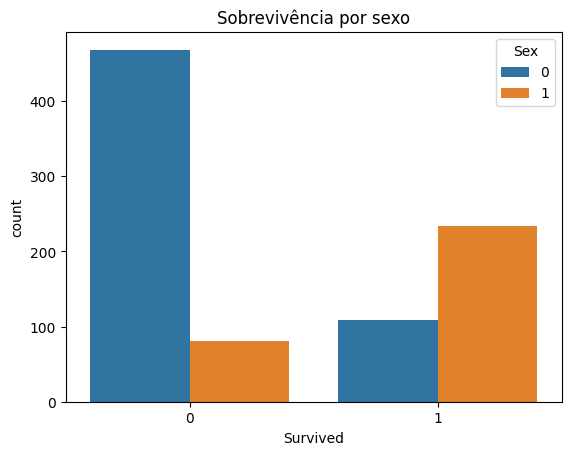

In [188]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Sobrevivência por sexo')
plt.show()

# Homem (0) e mulher (1)

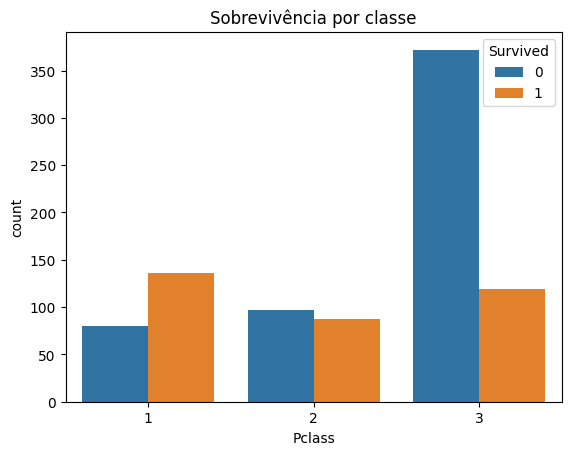

In [189]:
sns.countplot(x='Pclass', hue= 'Survived', data=df)
plt.title('Sobrevivência por classe')
plt.show()

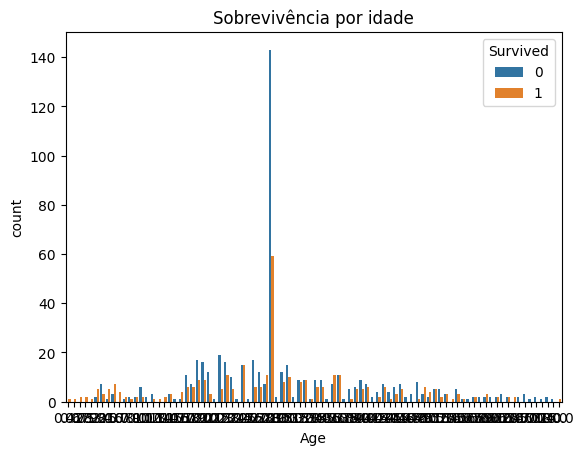

In [190]:
sns.countplot(x= 'Age', hue= 'Survived', data=df)
plt.title('Sobrevivência por idade')
plt.show()

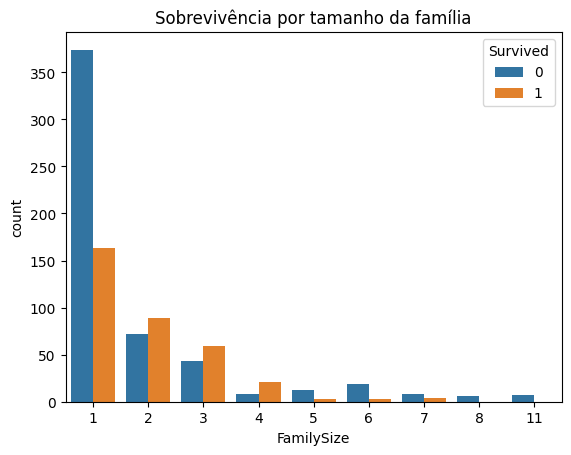

In [191]:
sns.countplot(x='FamilySize', hue= 'Survived', data=df)
plt.title('Sobrevivência por tamanho da família')
plt.show()

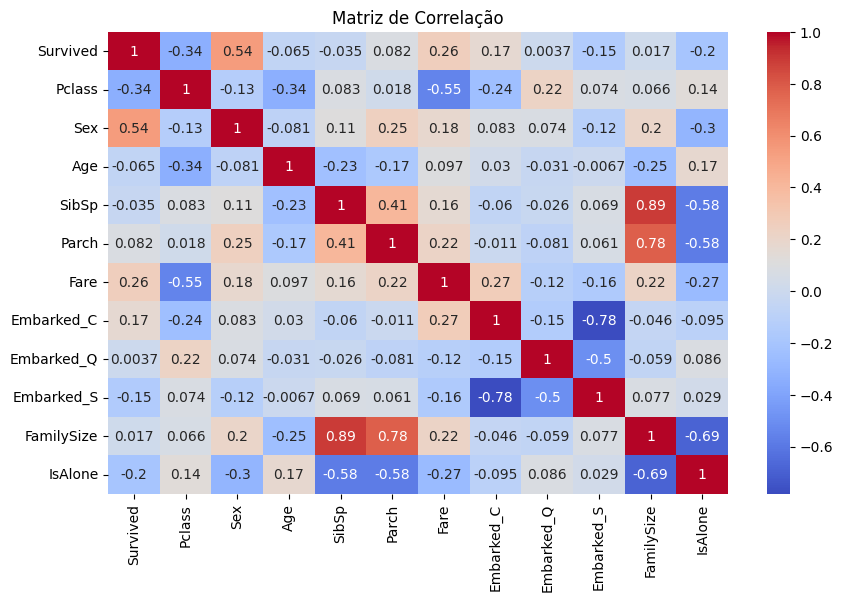

In [192]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

###**Machine Learning**

In [193]:
# Separar variáveis (X e y).

X = df.drop('Survived', axis=1)
y = df['Survived']

In [194]:
# Dividir dados em treino e teste.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 80% Treino e 20% Teste.

In [195]:
# Regrssão Logística - para problemas de classificação (0 ou 1).

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [196]:
# Previsões udando os dados de treino e teste.

predictions = model.predict(X_test)

In [197]:
# Avaliar o modelo.

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"Acurácia do modelo: {accuracy * 100:.2f}%")

Acurácia do modelo: 79.89%


In [198]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[89, 16],
       [20, 54]])

In [199]:
# Fazer previsões no dataset.

test = pd.read_csv("/content/test.csv")

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [200]:
# REALIZAR AS TRANSFORMAÇÕES EM TESTE IGUAL EM TREINO.

In [201]:
# Criar FarmilySize.

test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

In [202]:
# Converter sexo para número.

test["Sex"] = test["Sex"].map({"male": 0, "female": 1})

In [203]:
# Preencher idade faltante

test["Age"].fillna(test["Age"].median(), inplace=True)

/tmp/ipykernel_821/1951196233.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Age"].fillna(test["Age"].median(), inplace=True)


In [204]:
# Preencher Fare faltante.

test["Fare"].fillna(test["Fare"].median(), inplace=True)

/tmp/ipykernel_821/1666599304.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Fare"].fillna(test["Fare"].median(), inplace=True)


In [205]:
# Criar colunas de Embarked (One-Hot Encoding)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=False)

In [206]:
missing_cols = set(X_train.columns) - set(test.columns)

for col in missing_cols:
    test[col] = 0

In [207]:
X_test_final = test[X_train.columns]

In [208]:
# Fazer previsões.

predictions = model.predict(X_test_final)

In [209]:
# Criar o DataFrame de submissão.

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [210]:
submission.shape

(418, 2)

In [211]:
submission.to_csv("submission.csv", index=False)

In [212]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [213]:
y_pred_test = model.predict(X_test)      # avaliação do modelo
y_pred_kaggle = model.predict(X_test_final)  # submissão Kaggle

###**Avaliação completa do modelo**

In [214]:
y_pred_test = model.predict(X_test)

In [215]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



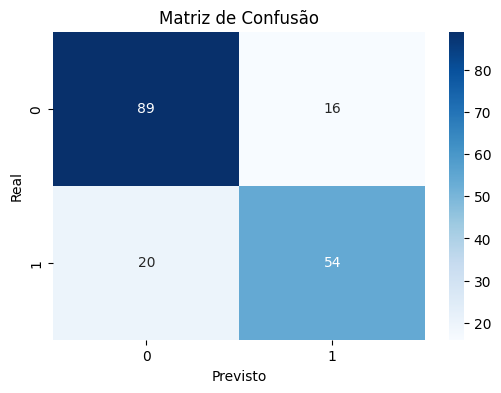

In [218]:
# Visualizar a Matriz de Confusão (gráfico).

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")

plt.show()

In [219]:
import pandas as pd

importance = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": model.coef_[0]
})

importance.sort_values(by="Coeficiente", ascending=False)

,Variavel,Coeficiente
1,Sex,2.536403
6,Embarked_C,0.142996
7,Embarked_Q,0.063924
5,Fare,0.002275
4,Parch,-0.013963
2,Age,-0.029839
8,Embarked_S,-0.211284
3,SibSp,-0.220857
9,FamilySize,-0.239183
10,IsAlone,-0.659520


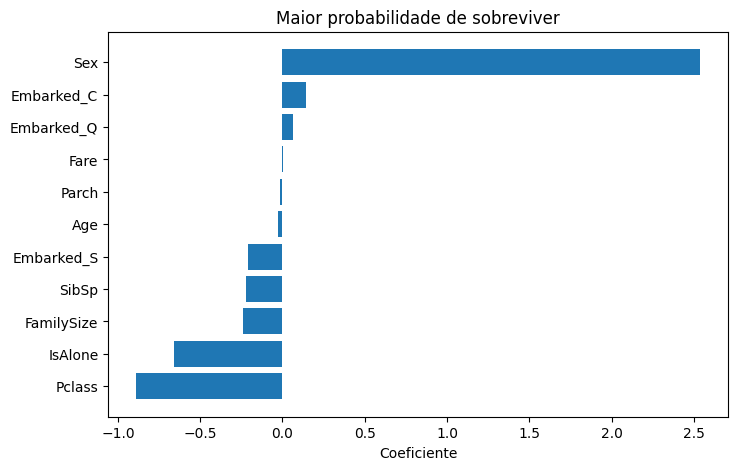

In [221]:
importance_sorted = importance.sort_values(by="Coeficiente")

plt.figure(figsize=(8,5))
plt.barh(importance_sorted["Variavel"], importance_sorted["Coeficiente"])
plt.title("Maior probabilidade de sobreviver")
plt.xlabel("Coeficiente")
plt.show()